
Logistic Regression
Accuracy Score:
0.9925135393437401

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       297
           1       0.97      0.98      0.98       239
           2       0.99      0.99      0.99       988
           3       1.00      1.00      1.00       893
           4       1.00      1.00      1.00       594
           5       0.99      0.99      0.99       795
           6       0.99      0.99      0.99      1183
           7       0.99      1.00      0.99       199
           8       1.00      1.00      1.00       398
           9       1.00      1.00      1.00       692

    accuracy                           0.99      6278
   macro avg       0.99      0.99      0.99      6278
weighted avg       0.99      0.99      0.99      6278


Decision Tree
Accuracy Score:
0.9851863650844218

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.9

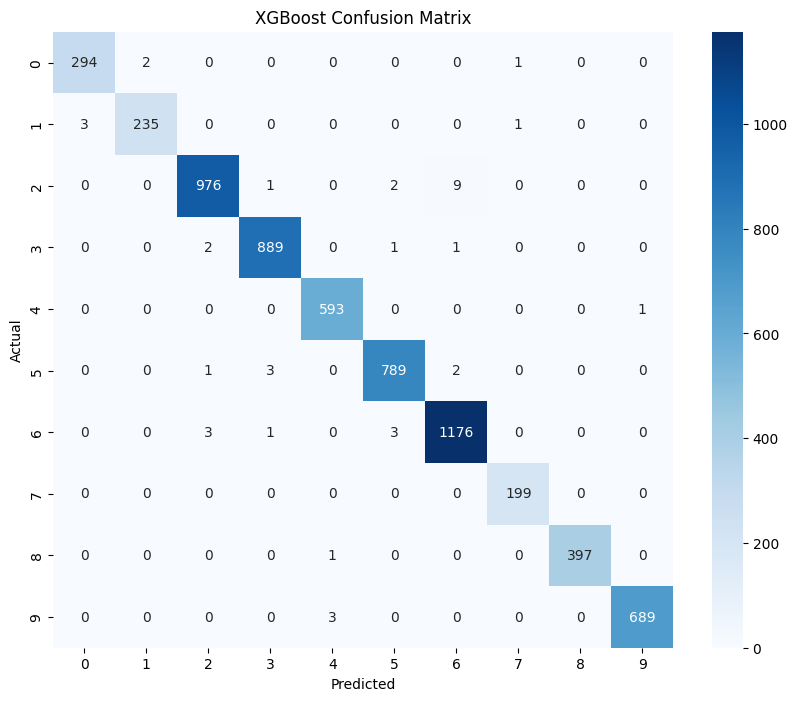

                 Model  Accuracy
0  Logistic Regression  0.992514
1        Decision Tree  0.985186
2        Random Forest  0.992354
3                  KNN  0.991558
4                  SVM  0.993788
5              XGBoost  0.993469
6    Gradient Boosting  0.993629
[0 5 6 3 5]


In [14]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

train_df=pd.read_csv("train_data.csv")
test_df=pd.read_csv("test_data.csv")

X_train = train_df.drop("target", axis=1)
y_train = train_df["target"]

X_test = test_df.drop("target", axis=1)
y_test = test_df["target"]

lr=LogisticRegression(
     max_iter=1000,
    class_weight='balanced'
)

lr.fit(X_train, y_train)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)


xgb = XGBClassifier(
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

# Decision Tree

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)


# KNN

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train, y_train)


# SVM

svm = SVC()

svm.fit(X_train, y_train)


# Gradient Boosting

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

def evaluate(model, name):

    pred = model.predict(X_test)

    print("\n==============================")
    print(name)
    print("==============================")

    print("Accuracy Score:")
    print(accuracy_score(y_test, pred))

    print("\nClassification Report:")
    print(classification_report(y_test, pred))

evaluate(lr, "Logistic Regression")

evaluate(dt, "Decision Tree")

evaluate(rf, "Random Forest")

evaluate(knn, "KNN")

evaluate(svm, "SVM")

evaluate(xgb, "XGBoost")

evaluate(gb, "Gradient Boosting")

pred_xgb = xgb.predict(X_test)

cm = confusion_matrix(y_test, pred_xgb)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM",
        "XGBoost",
        "Gradient Boosting"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, lr.predict(X_test)),
        accuracy_score(y_test, dt.predict(X_test)),
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, xgb.predict(X_test)),
        accuracy_score(y_test, gb.predict(X_test))
    ]
})

print(results)

import joblib

joblib.dump(xgb, "best_food_model.pkl")

loaded_model = joblib.load("best_food_model.pkl")

sample_prediction = loaded_model.predict(X_test.iloc[:5])

print(sample_prediction)



In [15]:
!pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
